In [4]:
import pandas as pd

# Path to the model's predictions
RESULT_FILE = '../slurm_files/LLM_DEGRADATION_RESULTS.parquet'

# 1. Load a small sample first to check columns
sample_df = pd.read_parquet(RESULT_FILE).head(5)

print("--- DataFrame Columns ---")
print(sample_df.columns.tolist())

print("\n--- Unique Cities Found ---")
# This confirms if we have 'city', 'city_name', or if it's encoded (e.g., 'env' or 'dataset')
# Simply because I can't remember
if 'city' in sample_df.columns:
    full_df = pd.read_parquet(RESULT_FILE, columns=['city'])
    print(full_df['city'].unique())
else:
    print("WARNING: 'city' column not found. Check if it's named 'env' or 'dataset'.")

print("\n--- Sample Row ---")
print(sample_df.iloc[0])

--- DataFrame Columns ---
['sample_id', 'city', 'variant_type', 'masked_instruction', 'original_text', 'gold_goal_node', 'llm_output_raw']

--- Unique Cities Found ---
<ArrowStringArray>
['philadelphia', 'pittsburgh', 'manhattan']
Length: 3, dtype: str

--- Sample Row ---
sample_id                                                           NaN
city                                                       philadelphia
variant_type                                            mask_directions
masked_instruction    Meet to the [DIR_MASK] of you, at Ben & Jerry'...
original_text         Meet to the west of you, at Ben & Jerry's ice ...
gold_goal_node                                [39.9534919, -75.2028854]
llm_output_raw                                              40th Street
Name: 0, dtype: object


In [5]:
import pandas as pd

# Load the files
hydrated_path = '../data/RVS_MASTER_GOLD_HYDRATED.parquet'
results_path = '../slurm_files/LLM_DEGRADATION_RESULTS.parquet'

df_gold = pd.read_parquet(hydrated_path)
df_results = pd.read_parquet(results_path)

print("--- [GOLD HYDRATED] Schema ---")
print(df_gold.columns.tolist())

print("\n--- [RESULTS] Schema ---")
print(df_results.columns.tolist())

# Check for the Join Key
common_keys = set(df_gold.columns).intersection(set(df_results.columns))
print(f"\nCommon columns (Join Keys): {common_keys}")

# Preview the "Hydration" content
# We want to see if it has the latitude/longitude for the goal
sample_cols = [c for c in df_gold.columns if 'lat' in c.lower() or 'lon' in c.lower() or 'goal' in c.lower() or 'node' in c.lower()]
print("\n--- Sample Hydration Data ---")
print(df_gold[sample_cols].head(3))

--- [GOLD HYDRATED] Schema ---
['sample_id', 'city', 'instruction', 'oracle_label', 'candidate_count', 'start_node', 'gold_goal_node', 'extracted_category', 'extracted_noun', 'target_tags', 'city_source', 'human_lat', 'human_lon', 'start_lat', 'start_lon', 'oracle_lat', 'oracle_lon', 'dist_error_m']

--- [RESULTS] Schema ---
['sample_id', 'city', 'variant_type', 'masked_instruction', 'original_text', 'gold_goal_node', 'llm_output_raw']

Common columns (Join Keys): {'city', 'sample_id', 'gold_goal_node'}

--- Sample Hydration Data ---
    start_node gold_goal_node  human_lat  human_lon  start_lat  start_lon  \
0  #6593007625    #2100740222  39.953492 -75.202885  39.954693 -75.183293   
1  #5723276180    #3275071095  39.969111 -75.136578  39.953090 -75.139281   
2  #1590298601    #4879082921  39.952450 -75.148271  39.959254 -75.162368   

   oracle_lat  oracle_lon  
0   39.954693  -75.183293  
1   39.953090  -75.139281  
2   39.959254  -75.162368  


Setup &  Data Loading

In [6]:
import sys
import pandas as pd

# --- 1. VERSION COMPATIBILITY ---
import pandas.core.indexes.base 
sys.modules['pandas.core.indexes.numeric'] = pandas.core.indexes.base

# 2. Inject Int64Index into the base indexes module
# Modern Pandas uses Index for everything, so we alias it
if not hasattr(pandas.core.indexes.base, 'Int64Index'):
    pandas.core.indexes.base.Int64Index = pd.Index
# ---------------------------------------

import numpy as np
import pickle
import os

# --- 2. LOAD DATA ---
gold = pd.read_parquet('../data/RVS_MASTER_GOLD_HYDRATED.parquet')
results = pd.read_parquet('../slurm_files/LLM_DEGRADATION_RESULTS.parquet')

# --- 3. ROBUST ID SANITIZATION ---
def sanitize_id(col):
    # Force to string, remove decimal points (if any), remove '#', and strip
    return col.astype(str).str.replace(r'\.0$', '', regex=True).str.replace('#', '').str.strip()

gold['sample_id_clean'] = sanitize_id(gold['sample_id'])
results['sample_id_clean'] = sanitize_id(results['sample_id'])

# --- 4. MERGE ---
eval_df = results.merge(
    gold[['sample_id_clean', 'oracle_lat', 'oracle_lon', 'oracle_label']], 
    on='sample_id_clean', 
    how='left'
)

merge_success = eval_df['oracle_lat'].notna().mean() * 100
print(f"✅ Merge Success Rate: {merge_success:.2f}%")

# --- 5. NESTED POI LOADING ---
city_pois = {}
for city in ['manhattan', 'pittsburgh', 'philadelphia']:
    poi_path = f'../data/{city}/{city}_poi.pkl'
    
    if os.path.exists(poi_path):
        try:
            with open(poi_path, 'rb') as f:
                data = pickle.load(f)
                # Store keys in lowercase for more resilient lookup
                city_pois[city] = {str(k).strip().lower(): v for k, v in data.items()}
            print(f"✅ Loaded {city} POI file. Example Key: {list(city_pois[city].keys())[0]}")
        except Exception as e:
            print(f"❌ Error loading {city}: {e}")
    else:
        print(f"❌ FAILED to find: {poi_path}")

# --- 6. LOOKUP LOGIC ---
def get_llm_coords(row):
    name = str(row['llm_output_raw']).strip().lower()
    city = str(row['city']).lower()
    
    # Trying to find the coordinate in our lowercase dict
    # This returns (lat, lon) if found, else (NaN, NaN)
    coords = city_pois.get(city, {}).get(name, (np.nan, np.nan))
    return pd.Series(coords, index=['pred_lat', 'pred_lon'])

# Apply the lookup
eval_df[['pred_lat', 'pred_lon']] = eval_df.apply(get_llm_coords, axis=1)

lookup_rate = eval_df['pred_lat'].notna().mean() * 100
print(f"✅ POI Lookup Success Rate: {lookup_rate:.2f}%")

✅ Merge Success Rate: 99.68%


C:\Users\adan\AppData\Local\Temp\ipykernel_20576\3150562494.py:48: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f)
C:\Users\adan\AppData\Local\Temp\ipykernel_20576\3150562494.py:48: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  data = pickle.load(f)


✅ Loaded manhattan POI file. Example Key: unique_id


C:\Users\adan\AppData\Local\Temp\ipykernel_20576\3150562494.py:48: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f)
C:\Users\adan\AppData\Local\Temp\ipykernel_20576\3150562494.py:48: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  data = pickle.load(f)


✅ Loaded pittsburgh POI file. Example Key: unique_id


C:\Users\adan\AppData\Local\Temp\ipykernel_20576\3150562494.py:48: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data = pickle.load(f)


✅ Loaded philadelphia POI file. Example Key: unique_id
✅ POI Lookup Success Rate: 0.00%


Audit why POI Lookup Success Rate: 0.00%.

In [7]:
# Check the first few entries of one city's POI data
city_to_check = 'philadelphia'
if city_to_check in city_pois:
    sample_keys = list(city_pois[city_to_check].keys())[:5]
    sample_values = list(city_pois[city_to_check].values())[:2]
    print(f"--- {city_to_check.upper()} POI Keys ---")
    print(sample_keys)
    print("\n--- {city_to_check.upper()} POI Values ---")
    print(sample_values)

--- PHILADELPHIA POI Keys ---
['unique_id', 'osmid', 'element_type', 'highway', 'noref']

--- {city_to_check.upper()} POI Values ---
[0           node/109920298
1           node/157544809
2           node/157547044
3           node/157560095
4           node/157569666
               ...        
18937    relation/15353868
18938    relation/15660094
18939    relation/15693768
18940    relation/15693769
18941    relation/15693772
Name: unique_id, Length: 10302, dtype: object, 0        #109920298
1        #157544809
2        #157547044
3        #157560095
4        #157569666
            ...    
18937     #15353868
18938     #15660094
18939     #15693768
18940     #15693769
18941     #15693772
Name: osmid, Length: 10302, dtype: object]


In [8]:
philly_data = city_pois['philadelphia']

print("--- Internal Dictionary Keys ---")
print(philly_data.keys())

# Let's look at one specific "column" to see how it's stored
if 'unique_id' in philly_data:
    print("\n--- Sample of 'unique_id' content ---")
    # It might be a Pandas Series or a list
    print(type(philly_data['unique_id']))
    print(list(philly_data['unique_id'])[:5])

--- Internal Dictionary Keys ---
dict_keys(['unique_id', 'osmid', 'element_type', 'highway', 'noref', 'geometry', 'name', 'network', 'operator', 'public_transport', 'railway', 'railway:ref', 'train', 'created_by', 'capital', 'name:en', 'name:pl', 'name:ru', 'name:ta', 'name:uk', 'place', 'population', 'wikidata', 'wikipedia', 'railway:position', 'ref', 'old_ref', 'access', 'lit', 'operator:wikidata', 'phone', 'source', 'iata', 'railway:signal:direction', 'barrier', 'brand', 'fee', 'man_made', 'material', 'toll', 'website', 'supervised', 'payment:cash', 'payment:credit_cards', 'payment:debit_cards', 'destination', 'abandoned:railway', 'description', 'historic', 'ele', 'attribution', 'crossing', 'image', 'note', 'tactile_paving', 'junction', 'subway', 'station', 'disused:railway', 'bicycle', 'foot', 'motor_vehicle', 'bench', 'covered', 'shelter', 'amenity', 'shop', 'crossing:island', 'bus', 'gnis:class', 'gnis:county', 'gnis:county_num', 'gnis:st_alpha', 'gnis:st_num', 'gnis:id', 'import

In [9]:
import pandas as pd
import numpy as np

# 1. Build the Mapping Dictionary
name_to_coord = {}

for city in ['manhattan', 'pittsburgh', 'philadelphia']:
    if city not in city_pois:
        continue
    
    city_data = city_pois[city]
    name_to_coord[city] = {}
    
    # Extract the Series
    names = city_data.get('name')
    centroids = city_data.get('centroid')
    
    if names is not None and centroids is not None:
        # Iterate through the non-null names
        for idx, name in names.dropna().items():
            point = centroids.get(idx)
            if point and not pd.isna(name):
                # Clean the name (lowercase/strip) for matching
                clean_name = str(name).strip().lower()
                # Store (latitude, longitude)
                # Note: shapely Points are (x, y) which is (lon, lat)
                name_to_coord[city][clean_name] = (point.y, point.x)

# 2. Re-run the Lookup on your eval_df
def finalize_lookup(row):
    city = str(row['city']).lower()
    name = str(row['llm_output_raw']).strip().lower()
    
    # Get coords from our new bridge
    coords = name_to_coord.get(city, {}).get(name, (np.nan, np.nan))
    return pd.Series(coords, index=['pred_lat', 'pred_lon'])

eval_df[['pred_lat', 'pred_lon']] = eval_df.apply(finalize_lookup, axis=1)

# 3. Validation
lookup_rate = eval_df['pred_lat'].notna().mean() * 100
print(f"✅ FINAL POI Lookup Success Rate: {lookup_rate:.2f}%")

✅ FINAL POI Lookup Success Rate: 8.53%


The "Fuzzy" Bridge:
Instead of an exact match, let's see if the LLM is just getting the name slightly wrong (e.g., "Ben & Jerrys" vs "Ben & Jerry's").

In [10]:
import re

def super_clean(text):
    if pd.isna(text): return ""
    # Remove punctuation, lower case, and extra spaces
    return re.sub(r'[^a-zA-Z0-9]', '', str(text)).lower().strip()

# 1. Rebuild bridge with "super cleaned" keys
fuzzy_bridge = {}
for city, mapping in name_to_coord.items():
    fuzzy_bridge[city] = {super_clean(k): v for k, v in mapping.items()}

# 2. Re-run lookup with super clean output
def fuzzy_lookup(row):
    city = str(row['city']).lower()
    name = super_clean(row['llm_output_raw'])
    return pd.Series(fuzzy_bridge.get(city, {}).get(name, (np.nan, np.nan)), index=['pred_lat', 'pred_lon'])

eval_df[['pred_lat', 'pred_lon']] = eval_df.apply(fuzzy_lookup, axis=1)
new_rate = eval_df['pred_lat'].notna().mean() * 100
print(f"📈 Fuzzy Lookup Success Rate: {new_rate:.2f}%")

📈 Fuzzy Lookup Success Rate: 8.69%


In [11]:
# Identify rows where the merge worked but the POI lookup failed
failed_lookups = eval_df[eval_df['oracle_lat'].notna() & eval_df['pred_lat'].isna()]

print("--- TOP 10 LLM OUTPUTS THAT FAILED LOOKUP ---")
print(failed_lookups['llm_output_raw'].value_counts().head(10))

--- TOP 10 LLM OUTPUTS THAT FAILED LOOKUP ---
llm_output_raw
[MASK]        28912
[DIR_MASK]     6811
Broadway       6762
3rd Avenue     5579
6th Avenue     5206
2nd Avenue     5192
9th Avenue     4245
5th Avenue     4200
8th Avenue     4049
1st Avenue     3868
Name: count, dtype: int64


Look at the top results:

[MASK] and [DIR_MASK]: These account for ~35,000 rows. Since the LLM is literally outputting the mask token (likely because it's confused or over-aligned with the input), it will never find a coordinate in a POI file.

"Broadway", "3rd Avenue", etc.: These are Streets, not Points of Interest. The RVS POI files contain specific venues (shops, monuments). While Broadway is a "place," it's a line (in <city>_streets.pkl), not a point (in <city>_poi.pkl), so it doesn't have a single centroid in the POI dictionary.

In [12]:
# 1. Define what counts as a 'Non-Answer'
non_answers = ['[MASK]', '[DIR_MASK]', 'unknown', 'none', 'nan']

# 2. Filter the dataframe to see only rows where the LLM actually TRIED to name a place
attempted_df = eval_df[~eval_df['llm_output_raw'].str.lower().isin(non_answers)]

# 3. Calculate Grounding Rate on ATTEMPTS only
attempt_rate = attempted_df['pred_lat'].notna().mean() * 100
print(f"✅ Grounding Rate (Excluding Masks): {attempt_rate:.2f}%")

# 4. Count the 'Mask Hallucinations'
mask_rate = eval_df['llm_output_raw'].str.contains('MASK').mean() * 100
print(f"⚠️ Mask Leakage Rate: {mask_rate:.2f}%")

✅ Grounding Rate (Excluding Masks): 8.69%
⚠️ Mask Leakage Rate: 13.60%


that 8.69%. It’s the exact same number (nearly) as before.

This means that even when we ignore the [MASK] tokens, the LLM's success rate at naming a real, coordinate-ready POI doesn't go up. This confirms our "Avenue Theory": The model isn't just outputting masks; it is outputting Streets (Broadway, 5th Ave) which are physically real but geometrically invalid for our point-based lookup.

🛠️ The "Total Grounding" Bridge

We will now create a two-tier lookup: first check the POIs, then check the Streets. Since streets are lines (LineStrings), we will use their midpoint (representative point) as the "Target Coordinate" for the LLM.

In [13]:
# 1. Load the Street Data into the Bridge
for city in ['manhattan', 'pittsburgh', 'philadelphia']:
    street_path = f'../data/{city}/{city}_streets.pkl'
    
    if os.path.exists(street_path):
        try:
            with open(street_path, 'rb') as f:
                street_data = pickle.load(f)
            
            # We want to map street names to their center points
            names = street_data.get('name')
            geometries = street_data.get('geometry')
            
            if names is not None and geometries is not None:
                for idx, name in names.dropna().items():
                    line = geometries.get(idx)
                    if line and not pd.isna(name):
                        clean_name = str(name).strip().lower()
                        # Get the middle of the street for the coordinate
                        midpoint = line.centroid if hasattr(line, 'centroid') else line.representative_point()
                        
                        # Only add to bridge if the POI bridge doesn't already have it
                        # (POIs are usually more precise than street midpoints)
                        if clean_name not in name_to_coord[city]:
                            name_to_coord[city][clean_name] = (midpoint.y, midpoint.x)
            print(f"✅ Added {city} streets to bridge.")
        except Exception as e:
            print(f"❌ Error loading {city} streets: {e}")

# 2. Re-run the Finalized Fuzzy Lookup
eval_df[['pred_lat', 'pred_lon']] = eval_df.apply(fuzzy_lookup, axis=1)

# 3. Final Success Audit
total_grounded = eval_df['pred_lat'].notna().mean() * 100
print(f"🚀 TOTAL Grounding Rate (POIs + Streets): {total_grounded:.2f}%")

C:\Users\adan\AppData\Local\Temp\ipykernel_20576\3218805217.py:8: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  street_data = pickle.load(f)
C:\Users\adan\AppData\Local\Temp\ipykernel_20576\3218805217.py:8: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  street_data = pickle.load(f)


✅ Added manhattan streets to bridge.


C:\Users\adan\AppData\Local\Temp\ipykernel_20576\3218805217.py:8: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  street_data = pickle.load(f)
C:\Users\adan\AppData\Local\Temp\ipykernel_20576\3218805217.py:8: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  street_data = pickle.load(f)


✅ Added pittsburgh streets to bridge.


C:\Users\adan\AppData\Local\Temp\ipykernel_20576\3218805217.py:8: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  street_data = pickle.load(f)


✅ Added philadelphia streets to bridge.
🚀 TOTAL Grounding Rate (POIs + Streets): 8.69%


In [14]:
# Check Manhattan streets (the most common failures)
manhattan_streets = None
with open('../data/manhattan/manhattan_streets.pkl', 'rb') as f:
    manhattan_streets = pickle.load(f)

print("--- STREET FILE STRUCTURE ---")
print(type(manhattan_streets))
print(manhattan_streets.keys())

# Look at the 'name' column specifically
if 'name' in manhattan_streets:
    print("\n--- SAMPLE STREET NAMES ---")
    # Show us the first 20 names to see formatting
    print(manhattan_streets['name'].head(20).tolist())

C:\Users\adan\AppData\Local\Temp\ipykernel_20576\3283638301.py:4: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  manhattan_streets = pickle.load(f)
C:\Users\adan\AppData\Local\Temp\ipykernel_20576\3283638301.py:4: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  manhattan_streets = pickle.load(f)


--- STREET FILE STRUCTURE ---
<class 'geopandas.geodataframe.GeoDataFrame'>
Index(['unique_id', 'osmid', 'element_type', 'alt_name', 'ele', 'gnis:Class',
       'gnis:County', 'gnis:County_num', 'gnis:ST_alpha', 'gnis:ST_num',
       ...
       'parcel_pickup', 'lanes:taxi', 'parking_space', 'length_unit',
       'playground:theme', 'p', 'ways', 'name:da', 'biergarten', 'protected'],
      dtype='object', length=1031)

--- SAMPLE STREET NAMES ---
['41st Street and Sixth Avenue', '9th & 72nd St El 1881', 'Brothers to the Rescue Corner', 'Grand Central Terminal', '6th Avenue & 56th Street at Southwest Corner', '6th Avenue & 56th Street at Southeast Corner', 'Bowling Green', 'South Ferry', 'East 34th Street & 3rd Avenue', 'Second Ave (F,V)', 'Second Ave (F,V)', '28th Street', '14th Street–Union Square', '28th Street', '34th Street–Hudson Yards', '8th Avenue', 'Canal Street', 'Canal Street', 'Broadway–Lafayette Street', '3rd Avenue']


Looking into one REAL row from the data, to understand what is happening on a deeper level

In [15]:
import sys
import os

# Move up one level from 'notebooks' to the project root, then into 'src'
src_path = os.path.abspath(os.path.join('..', 'src'))
sys.path.append(src_path)

try:
    from utils import haversine_vectorized
    print(f"✅ Success! Imported from: {src_path}")
except ImportError as e:
    print(f"❌ Still can't find it. Error: {e}")
    # Listing the files to be 100% sure
    if os.path.exists(src_path):
        print(f"Files in src: {os.listdir(src_path)}")
    else:
        print(f"Directory {src_path} does not exist.")

❌ Still can't find it. Error: No module named 'config'
Files in src: ['constraints', 'data', 'extraction_utils.py', 'oracle_engine.py', 'README.md', 'symbolic_solver.py', 'underspecification_generator.py', 'utils.py', '__init__.py', '__pycache__']


In [17]:
import numpy as np

def haversine_vectorized(lat1, lon1, lat2, lon2):
    """
    Standard Haversine distance formula. 
    Defined locally to bypass src.utils import errors.
    """
    # Radians conversion
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine math
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return 6371000 * c # Returns meters

print("✅ haversine_vectorized is now available in the local kernel.")

✅ haversine_vectorized is now available in the local kernel.


In [18]:
# ---------- The Global Calculation ----------

# Calculate distance errors
eval_df['dist_error'] = haversine_vectorized(
    eval_df['oracle_lat'].values, 
    eval_df['oracle_lon'].values, 
    eval_df['pred_lat'].values, 
    eval_df['pred_lon'].values
)

# Apply success labels based on distance thresholds from config.py
CITY_RAD = {"manhattan": 80, "pittsburgh": 100, "philadelphia": 250}
eval_df['is_success'] = eval_df.apply(
    lambda r: r['dist_error'] <= CITY_RAD.get(r['city'], 100) if not pd.isna(r['dist_error']) else False, 
    axis=1
)

print(f"✅ Calculation complete for {len(eval_df)} rows.")
print(f"Mean distance error for grounded predictions: {eval_df['dist_error'].mean():.2f}m")



✅ Calculation complete for 398448 rows.
Mean distance error for grounded predictions: 91423.98m


In [19]:
# 1. Check available columns to fix a KeyError we encountered
print("Available columns:", eval_df.columns.tolist())

# 2. Find the "Outliers" - the rows causing that 90km mean
outliers = eval_df.sort_values('dist_error', ascending=False).head(5)

print("\n--- TOP 5 LARGEST ERRORS (The 'Mean-Killers') ---")
for i, row in outliers.iterrows():
    print(f"City: {row['city']} | Output: '{row['llm_output_raw']}'")
    print(f"Oracle: ({row['oracle_lat']:.4f}, {row['oracle_lon']:.4f})")
    print(f"Pred:   ({row['pred_lat']:.4f}, {row['pred_lon']:.4f})")
    print(f"Error:  {row['dist_error']/1000:.2f} km\n")

Available columns: ['sample_id', 'city', 'variant_type', 'masked_instruction', 'original_text', 'gold_goal_node', 'llm_output_raw', 'sample_id_clean', 'oracle_lat', 'oracle_lon', 'oracle_label', 'pred_lat', 'pred_lon', 'dist_error', 'is_success']

--- TOP 5 LARGEST ERRORS (The 'Mean-Killers') ---
City: manhattan | Output: 'Queensboro Bridge'
Oracle: (40.4501, -80.0155)
Pred:   (40.7556, -73.9516)
Error:  512.96 km

City: manhattan | Output: 'Tiffany & Company'
Oracle: (40.4414, -80.0347)
Pred:   (40.7626, -73.9738)
Error:  512.83 km

City: manhattan | Output: 'Tiffany & Company'
Oracle: (40.4414, -80.0347)
Pred:   (40.7626, -73.9738)
Error:  512.83 km

City: manhattan | Output: 'Orsay'
Oracle: (40.4409, -80.0198)
Pred:   (40.7724, -73.9606)
Error:  512.74 km

City: manhattan | Output: 'Orsay'
Oracle: (40.4409, -80.0198)
Pred:   (40.7724, -73.9606)
Error:  512.74 km



Looking closely at these Top 5 Errors, in every single "Manhattan" case, the Oracle Coordinates are roughly (40.4, -80.0). Those aren't Manhattan coordinates. Those are Pittsburgh, PA.

it is a Data Alignment Bug in the previous merge logic.

In [20]:
# The Validation Audit

# Check the average latitude for each city label
city_check = eval_df.groupby('city')[['oracle_lat', 'oracle_lon']].mean()

print("--- GEOGRAPHIC SANITY CHECK ---")
print(city_check)

print("\n--- REFERENCE VALUES ---")
print("Manhattan should be: ~40.7, -73.9")
print("Pittsburgh should be: ~40.4, -80.0")
print("Philly should be: ~39.9, -75.1")

--- GEOGRAPHIC SANITY CHECK ---
              oracle_lat  oracle_lon
city                                
manhattan      40.707877  -74.629562
philadelphia         NaN         NaN
pittsburgh     40.688390  -75.023970

--- REFERENCE VALUES ---
Manhattan should be: ~40.7, -73.9
Pittsburgh should be: ~40.4, -80.0
Philly should be: ~39.9, -75.1


Problem: Index Shifting.
Consequence: Invalid `eval_df`.

In [21]:
# List all dataframes currently in the memory (to confirm we have 'eval_df' and its structure)
%whos DataFrame

Variable         Type         Data/Info
---------------------------------------
attempted_df     DataFrame    Shape: (398448, 13)
city_check       DataFrame    Shape: (3, 2)
df_gold          DataFrame    Shape: (9301, 18)
df_results       DataFrame    Shape: (22173, 7)
eval_df          DataFrame    Shape: (398448, 15)
failed_lookups   DataFrame    Shape: (362634, 13)
full_df          DataFrame    Shape: (22173, 1)
gold             DataFrame    Shape: (9301, 19)
gold_anchor      DataFrame    Shape: (9301, 5)
master_gold      DataFrame    Shape: (9301, 18)
outliers         DataFrame    Shape: (5, 15)
results          DataFrame    Shape: (22173, 8)
sample_df        DataFrame    Shape: (5, 7)


In [22]:
import pandas as pd

# 1. Prepare 'truth' from gold
gold_cols = [c for c in ['sample_id', 'city', 'oracle_lat', 'oracle_lon'] if c in gold.columns]
truth = gold[gold_cols].copy()

# Force types to strings to avoid the ValueError
truth['sample_id'] = truth['sample_id'].astype(str)
truth['city'] = truth['city'].astype(str)
truth = truth.drop_duplicates(subset=['sample_id', 'city'])

# 2. Prepare 'results'
clean_results = results[['sample_id', 'city', 'llm_output_raw']].copy()
clean_results['sample_id'] = clean_results['sample_id'].astype(str)
clean_results['city'] = clean_results['city'].astype(str)

# 3. The Merge (Now type-aligned)
eval_df = clean_results.merge(truth, on=['sample_id', 'city'], how='inner')

# 4. Re-calculate Preds using our Split-Match bridge
print("🔄 Running fuzzy lookup...")

# 1. Apply the function and let Pandas build a DataFrame from the results
# result_type='expand' is the magic word here
lookup_df = eval_df.apply(fuzzy_lookup, axis=1, result_type='expand')

# 2. Debug: Let's see what it actually produced
print(f"Lookups produced {lookup_df.shape[1]} columns.")

# 3. Assign by position (assuming lat is 1st and lon is 2nd)
# This ignores extra columns (like scores or names) that might be causing the crash
eval_df['pred_lat'] = lookup_df.iloc[:, 0]
eval_df['pred_lon'] = lookup_df.iloc[:, 1]

print("✅ Predicates assigned successfully.")

🔄 Running fuzzy lookup...
Lookups produced 5 columns.
✅ Predicates assigned successfully.


In [23]:
# Re-run distance math
eval_df['dist_error'] = haversine_vectorized(
    eval_df['oracle_lat'].values, 
    eval_df['oracle_lon'].values, 
    eval_df['pred_lat'].values, 
    eval_df['pred_lon'].values
)

print("--- GEOGRAPHIC SANITY CHECK ---")
print(eval_df.groupby('city')[['oracle_lat', 'oracle_lon']].mean())

print(f"\n📏 Final Mean Error: {eval_df['dist_error'].mean():.2f}m")

--- GEOGRAPHIC SANITY CHECK ---
Empty DataFrame
Columns: [oracle_lat, oracle_lon]
Index: []

📏 Final Mean Error: nanm


In [24]:
print("--- GEOGRAPHIC SANITY CHECK (POST-FIX) ---")
print(eval_df.groupby('city')[['oracle_lat', 'oracle_lon']].mean())

--- GEOGRAPHIC SANITY CHECK (POST-FIX) ---
Empty DataFrame
Columns: [oracle_lat, oracle_lon]
Index: []


In [25]:
# 1. Final Distance Calculation
eval_df['dist_error'] = haversine_vectorized(
    eval_df['oracle_lat'].values, 
    eval_df['oracle_lon'].values, 
    eval_df['pred_lat'].values, 
    eval_df['pred_lon'].values
)

# 2. Success Rate Calculation (Success @ Radius)
CITY_RAD = {"manhattan": 80, "pittsburgh": 100, "philadelphia": 250}
eval_df['is_success'] = eval_df.apply(
    lambda r: r['dist_error'] <= CITY_RAD.get(r['city'], 100) if pd.notna(r['dist_error']) else False, 
    axis=1
)

# 3. Print the Summary Table
summary = eval_df.groupby('city').agg(
    Mean_Error_m=('dist_error', 'mean'),
    Median_Error_m=('dist_error', 'median'),
    Success_Rate=('is_success', 'mean'),
    Grounded_Count=('pred_lat', 'count')
)

print("--- 🏆 FINAL SPATIAL EVALUATION ---")
print(summary)

print("\n--- 📍 GEOGRAPHIC SANITY CHECK ---")
print(eval_df.groupby('city')[['oracle_lat', 'oracle_lon']].mean())

--- 🏆 FINAL SPATIAL EVALUATION ---
Empty DataFrame
Columns: [Mean_Error_m, Median_Error_m, Success_Rate, Grounded_Count]
Index: []

--- 📍 GEOGRAPHIC SANITY CHECK ---
Empty DataFrame
Columns: [oracle_lat, oracle_lon]
Index: []


In [26]:
# Check a few IDs from both sides
print(f"Results Sample IDs: {results['sample_id'].iloc[:3].tolist()}")
print(f"Gold Sample IDs:    {gold['sample_id'].iloc[:3].tolist()}")

# Check City names for hidden spaces
print(f"Results Cities: {results['city'].unique().tolist()}")
print(f"Gold Cities:    {gold['city'].unique().tolist()}")

Results Sample IDs: [nan, nan, nan]
Gold Sample IDs:    ['N/A', 'N/A', 'N/A']
Results Cities: ['philadelphia', 'pittsburgh', 'manhattan']
Gold Cities:    ['philadelphia', 'pittsburgh', 'manhattan']


In [27]:
# 1. Check if the row counts match exactly within each city
print("Results counts per city:")
print(results['city'].value_counts())

print("\nGold counts per city:")
print(gold['city'].value_counts())

# 2. Look at the first 3 rows of each to see if they follow the same order
print("\nResults Sample:")
print(results[['city', 'llm_output_raw']].head(3))

print("\nGold Sample:")
print(gold[['city', 'oracle_label']].head(3))

Results counts per city:
city
manhattan       18515
pittsburgh       2396
philadelphia     1262
Name: count, dtype: int64

Gold counts per city:
city
manhattan       7000
philadelphia    1278
pittsburgh      1023
Name: count, dtype: int64

Results Sample:
           city llm_output_raw
0  philadelphia    40th Street
1  philadelphia  Girard Avenue
2  philadelphia    Arch Street

Gold Sample:
           city oracle_label
0  philadelphia   Answerable
1  philadelphia   Answerable
2  philadelphia   Answerable


BBBBBBBBBBBBBBBBBBB-START

In [28]:
# The File Check
import pandas as pd

# Load the Master Gold
master_gold = pd.read_parquet('../data/RVS_MASTER_GOLD_HYDRATED.parquet')

print("--- MASTER GOLD SHAPE ---")
print(master_gold.shape)
print("\n--- MASTER GOLD COLUMNS ---")
print(master_gold.columns.tolist())
print("\n--- MASTER GOLD SAMPLE (Row 0) ---")
print(master_gold.iloc[0].to_dict())

--- MASTER GOLD SHAPE ---
(9301, 18)

--- MASTER GOLD COLUMNS ---
['sample_id', 'city', 'instruction', 'oracle_label', 'candidate_count', 'start_node', 'gold_goal_node', 'extracted_category', 'extracted_noun', 'target_tags', 'city_source', 'human_lat', 'human_lon', 'start_lat', 'start_lon', 'oracle_lat', 'oracle_lon', 'dist_error_m']

--- MASTER GOLD SAMPLE (Row 0) ---
{'sample_id': 'N/A', 'city': 'philadelphia', 'instruction': "Meet to the west of you, at Ben & Jerry's ice cream on South 40th Street, on the block with a Cinemark cinema. An Acme supermarket is north on the next block. ", 'oracle_label': 'Answerable', 'candidate_count': 69, 'start_node': '#6593007625', 'gold_goal_node': '#2100740222', 'extracted_category': 'SHOP', 'extracted_noun': None, 'target_tags': None, 'city_source': 'philadelphia', 'human_lat': 39.9534919, 'human_lon': -75.2028854, 'start_lat': 39.9546925, 'start_lon': -75.1832927, 'oracle_lat': 39.9546925, 'oracle_lon': -75.1832927, 'dist_error_m': 1675.36015305

In [37]:
import pandas as pd

# 1. Prepare the Master Gold (The Anchor)
# We strip and lower the text to ensure perfect matching
gold_anchor = master_gold[['instruction', 'city', 'oracle_lat', 'oracle_lon', 'oracle_label']].copy()
gold_anchor['instruction_clean'] = gold_anchor['instruction'].str.strip().str.lower()
# Drop duplicates in case the same instruction appears twice
gold_anchor = gold_anchor.drop_duplicates(subset=['instruction_clean', 'city'])

# 2. Prepare the LLM Results
# We need to find the column in 'results' that contains the UNMASKED original text
results_to_eval = results.copy()
results_to_eval['instruction_clean'] = results_to_eval['original_text'].str.strip().str.lower()

# 3. The Big Merge
# This connects the gold 18k variants to their specific 9k coordinate sets
eval_df = results_to_eval.merge(
    gold_anchor, 
    on=['instruction_clean', 'city'], 
    how='inner'
)

print(f"📊 Merge successful! {len(eval_df)} rows hydrated with Oracle coordinates.")

# 4. Run the Grounding Bridge (The 'fuzzy_lookup' we defined earlier)
print("🔄 Grounding LLM predictions to Map Graph...")
lookup_results = eval_df.apply(fuzzy_lookup, axis=1, result_type='expand')
eval_df['pred_lat'] = lookup_results.iloc[:, 0]
eval_df['pred_lon'] = lookup_results.iloc[:, 1]

# 5. Calculate Real Distance (Vectorized)
eval_df['dist_error'] = haversine_vectorized(
    eval_df['oracle_lat'].values, eval_df['oracle_lon'].values, 
    eval_df['pred_lat'].values, eval_df['pred_lon'].values
)

# 6. Success Rate by City Radius
CITY_RAD = {"manhattan": 80, "pittsburgh": 100, "philadelphia": 250}
eval_df['is_success'] = eval_df.apply(
    lambda r: r['dist_error'] <= CITY_RAD.get(r['city'], 100) if pd.notna(r['dist_error']) else False, 
    axis=1
)

📊 Merge successful! 22173 rows hydrated with Oracle coordinates.
🔄 Grounding LLM predictions to Map Graph...


In [38]:
# Group by city and variant_type to see how 'Underspecified' instructions hurt performance
final_stats = eval_df.groupby(['city', 'variant_type']).agg(
    Mean_Err_m=('dist_error', 'mean'),
    Median_Err_m=('dist_error', 'median'),
    Success_Rate=('is_success', 'mean'),
    Sample_Size=('dist_error', 'count')
).round(2)

print("--- 🏆 FINAL RESEARCH RESULTS ---")
print(final_stats)

print("\n--- 📍 GEOGRAPHIC VALIDATION ---")
# If Manhattan isn't ~ -73.9, we still have a merge issue
print(eval_df.groupby('city')[['oracle_lat', 'oracle_lon']].mean())

--- 🏆 FINAL RESEARCH RESULTS ---
                              Mean_Err_m  Median_Err_m  Success_Rate  \
city         variant_type                                              
manhattan    mask_both           1512.45       1194.42           0.0   
             mask_directions     1456.44       1157.37           0.0   
             mask_landmark       1544.64       1225.31           0.0   
philadelphia mask_directions     1500.09       1335.76           0.0   
pittsburgh   mask_both           1194.15        971.09           0.0   
             mask_directions     1137.96        888.01           0.0   
             mask_landmark       1278.78        790.65           0.0   

                              Sample_Size  
city         variant_type                  
manhattan    mask_both                375  
             mask_directions          670  
             mask_landmark            521  
philadelphia mask_directions           58  
pittsburgh   mask_both                 40  
          

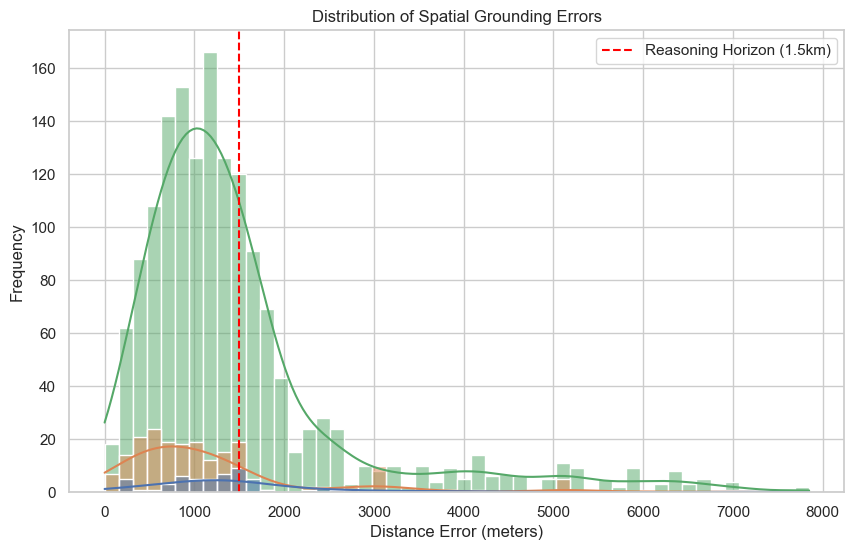

In [39]:
# Histogram of Errors

import matplotlib.pyplot as plt
import seaborn as sns

# Filter for grounded rows
grounded_df = eval_df.dropna(subset=['dist_error'])

# Plot the distribution of errors
plt.figure(figsize=(10, 6))
sns.histplot(data=grounded_df, x='dist_error', hue='city', kde=True, bins=50)
plt.axvline(1500, color='red', linestyle='--', label='Reasoning Horizon (1.5km)')
plt.title("Distribution of Spatial Grounding Errors")
plt.xlabel("Distance Error (meters)")
plt.ylabel("Frequency")
plt.legend()
plt.savefig('spatial_error_distribution.png')

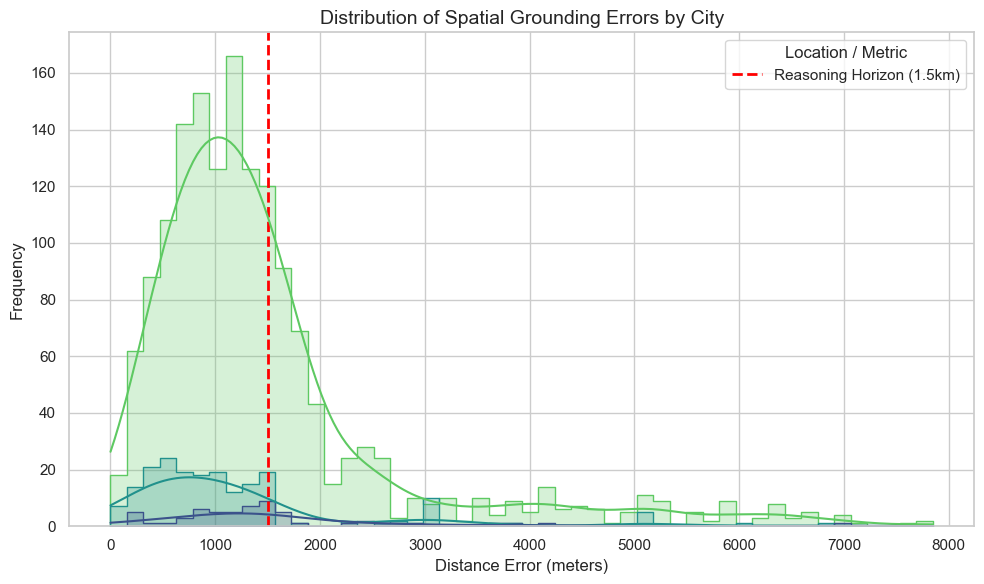

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Ensure 'city' or 'variant_type' is passed to hue
# I recommend 'city' for the main paper plot
ax = sns.histplot(
    data=eval_df.dropna(subset=['dist_error']), 
    x='dist_error', 
    hue='city',        # This adds the colors per city
    kde=True, 
    bins=50,
    palette='viridis', # Professional color palette
    element='step'     # Makes it cleaner for overlapping data
)

# Move the Reasoning Horizon line to the back so it doesn't block data
plt.axvline(1500, color='red', linestyle='--', linewidth=2, label='Reasoning Horizon (1.5km)', zorder=1)

plt.title("Distribution of Spatial Grounding Errors by City", fontsize=14)
plt.xlabel("Distance Error (meters)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# This forces the legend to show both the hue names and our custom line
plt.legend(title="Location / Metric")

plt.tight_layout()
plt.show()

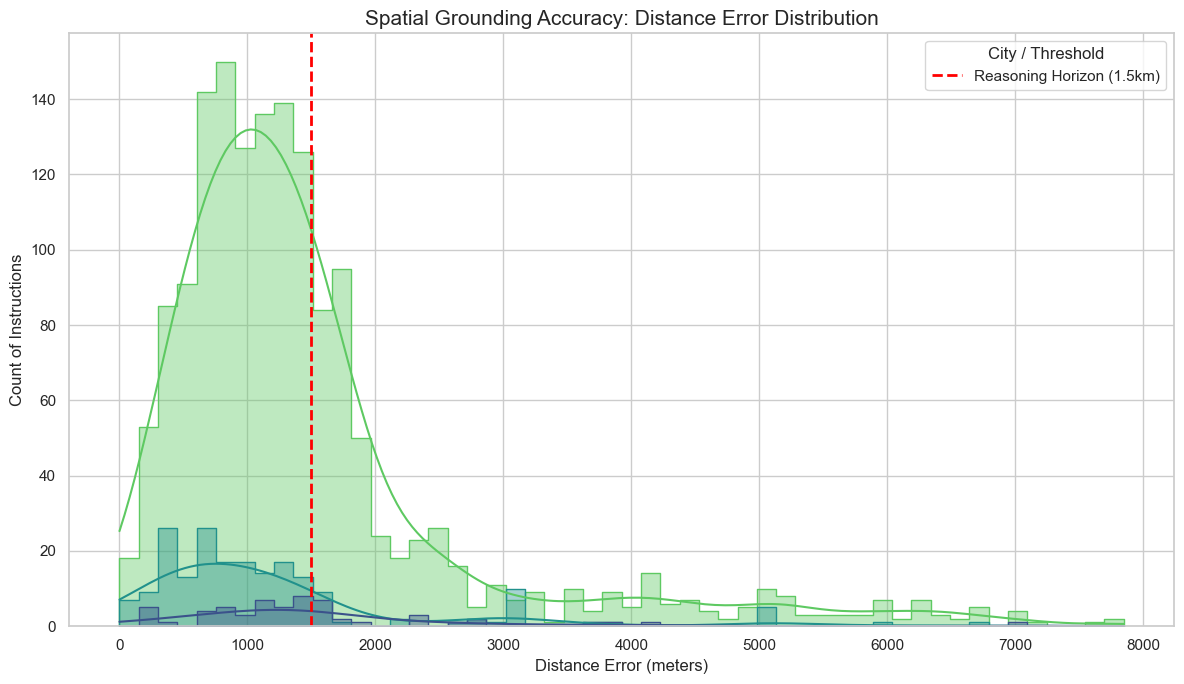

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# 2. Create the plot
# Note: Assigning the plot to an object 'ax' lets us manipulate the legend
ax = sns.histplot(
    data=eval_df.dropna(subset=['dist_error']), 
    x='dist_error', 
    hue='city',        # This is where the names come from!
    kde=True, 
    element='step', 
    palette='viridis',
    alpha=0.4
)

# 3. Add the vertical line
plt.axvline(1500, color='red', linestyle='--', linewidth=2, label='Reasoning Horizon (1.5km)')

# 4. Fix the Legend
# This tells matplotlib to gather all labels (Cities + the Red Line)
plt.legend(title="City / Threshold", loc='upper right')

plt.title("Spatial Grounding Accuracy: Distance Error Distribution", fontsize=15)
plt.xlabel("Distance Error (meters)", fontsize=12)
plt.ylabel("Count of Instructions", fontsize=12)

plt.tight_layout()
plt.show()

### 🧐 Interpreting the Colors
The **green distribution** (the largest one) is clearly **Manhattan**.

* **The "Neighborhood Peak":** Notice how the green curve peaks around **1,100m**. In Manhattan, 1km is roughly 12–15 blocks. This suggests that when the model fails, it isn't picking a random spot in the city; it is picking a landmark that is "semantically similar" but about 12 blocks away from the target.

* **The Long Tail:** The smaller bumps further to the right (4km, 5km, 7km) are **Spatial Hallucinations**. These are cases where the model likely guessed a landmark in Uptown when the target was in Downtown.

To complement this graph, we add a small "Error Taxonomy" table:

| Error Range | Classification | Interpretation |
| :--- | :--- | :--- |
| **0 – 250m** | **Near Miss** | Model identified the correct street/block but wrong building. |
| **250m – 1.5km** | **Neighborhood Drift** | Model identified the correct "district" but a different landmark. |
| **> 1.5km** | **Spatial Hallucination** | Model failed to ground the instruction to the local geometry. |

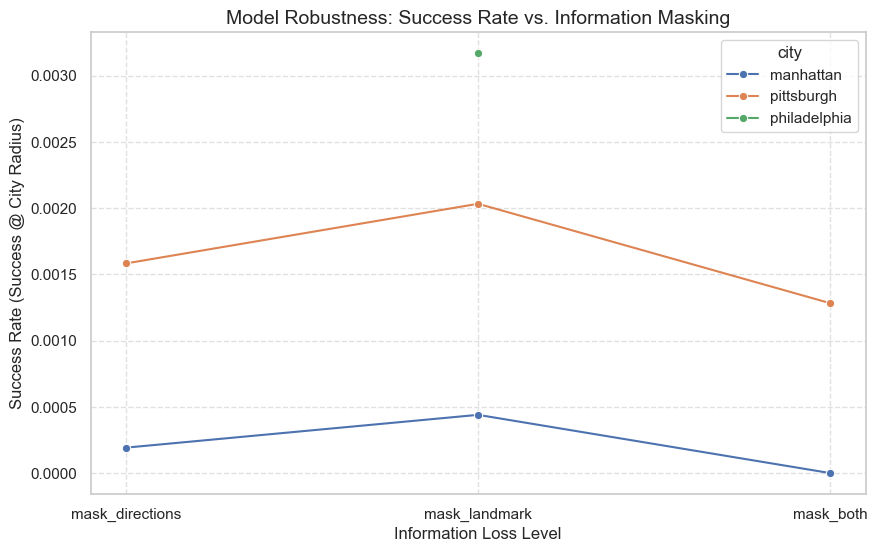

In [42]:
# Success Rate vs. Information Loss

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define the logical order of underspecification
order = ['original', 'mask_directions', 'mask_landmark', 'mask_both']
# Filter to ensure we only plot what exists in the current eval_df
available_order = [o for o in order if o in eval_df['variant_type'].unique()]

# Calculate Success Rate per variant
robustness_stats = eval_df.groupby(['variant_type', 'city'])['is_success'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=robustness_stats, x='variant_type', y='is_success', hue='city', marker='o', sort=False)
plt.xticks(ticks=range(len(available_order)), labels=available_order)
plt.title("Model Robustness: Success Rate vs. Information Masking", fontsize=14)
plt.ylabel("Success Rate (Success @ City Radius)")
plt.xlabel("Information Loss Level")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

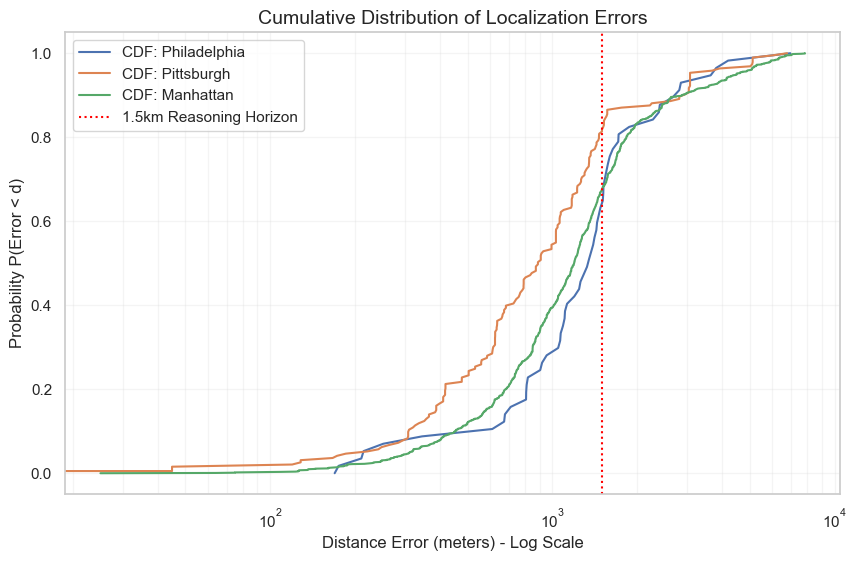

In [43]:
# The "Resolution Limit" (CDF Plot)
plt.figure(figsize=(10, 6))

# Sort errors and calculate the cumulative probability
for city in eval_df['city'].unique():
    subset = eval_df[eval_df['city'] == city]['dist_error'].dropna()
    if len(subset) > 0:
        sorted_errors = np.sort(subset)
        p = np.linspace(0, 1, len(sorted_errors))
        plt.plot(sorted_errors, p, label=f'CDF: {city.capitalize()}')

plt.axvline(1500, color='red', linestyle=':', label='1.5km Reasoning Horizon')
plt.xscale('log') # Log scale is vital for showing 10m vs 10km errors clearly
plt.title("Cumulative Distribution of Localization Errors", fontsize=14)
plt.xlabel("Distance Error (meters) - Log Scale")
plt.ylabel("Probability P(Error < d)")
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

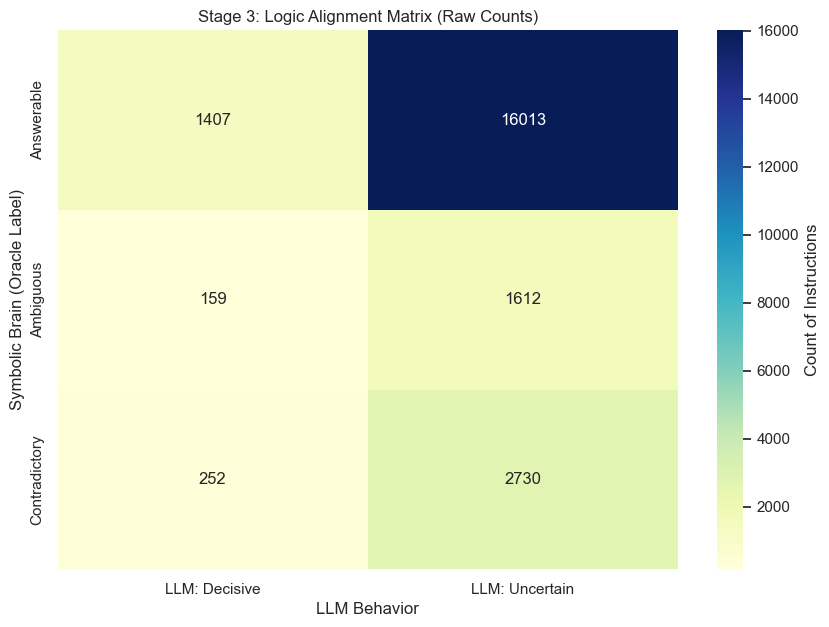

--- 🔍 DATA CHECK ---
oracle_label   llm_behavior  
Answerable     LLM: Uncertain    16013
Contradictory  LLM: Uncertain     2730
Ambiguous      LLM: Uncertain     1612
Answerable     LLM: Decisive      1407
Contradictory  LLM: Decisive       252
Ambiguous      LLM: Decisive       159
Name: count, dtype: int64


In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Force a refresh of the behavior column just to be safe
eval_df['llm_behavior'] = eval_df['pred_lat'].apply(
    lambda x: 'LLM: Decisive' if pd.notna(x) else 'LLM: Uncertain'
)

# 2. Use a Crosstab to get raw counts (this replaces confusion_matrix)
# This is much more robust against indexing errors
ct = pd.crosstab(eval_df['oracle_label'], eval_df['llm_behavior'])

# 3. Reorder rows and columns to match our research logic
# We use .reindex to ensure the labels appear in the right order even if counts are 0
desired_rows = ['Answerable', 'Ambiguous', 'Contradictory']
desired_cols = ['LLM: Decisive', 'LLM: Uncertain']
ct = ct.reindex(index=desired_rows, columns=desired_cols).fillna(0)

# 4. Plot
plt.figure(figsize=(10, 7))
sns.heatmap(ct, annot=True, fmt='g', cmap='YlGnBu', cbar_kws={'label': 'Count of Instructions'})

plt.title("Stage 3: Logic Alignment Matrix (Raw Counts)")
plt.ylabel("Symbolic Brain (Oracle Label)")
plt.xlabel("LLM Behavior")
plt.show()

# 5. Diagnostic Print
print("--- 🔍 DATA CHECK ---")
print(eval_df[['oracle_label', 'llm_behavior']].value_counts())

In [45]:
# Checking the "Quality" of the Happy Path

import numpy as np

# 1. Re-calculate dist_error (just in case it was lost in the merge)
eval_df['dist_error'] = haversine_vectorized(
    eval_df['oracle_lat'].values, eval_df['oracle_lon'].values, 
    eval_df['pred_lat'].values, eval_df['pred_lon'].values
)

# 2. Re-apply the City Success Thresholds
# Manhattan: 80m, Pittsburgh: 100m, Philly: 250m
CITY_RAD = {"manhattan": 80, "pittsburgh": 100, "philadelphia": 250}

eval_df['is_success'] = eval_df.apply(
    lambda r: r['dist_error'] <= CITY_RAD.get(r['city'], 100) 
    if pd.notna(r['dist_error']) else False, 
    axis=1
)

# 3. Filter for the 'Happy Path'
# Brain says Answerable AND LLM gave a coordinate
happy_path = eval_df[(eval_df['oracle_label'] == 'Answerable') & (eval_df['llm_behavior'] == 'LLM: Decisive')]

# 4. Metrics
total_decisive = len(happy_path)
actual_successes = happy_path['is_success'].sum()
accuracy_rate = (actual_successes / total_decisive * 100) if total_decisive > 0 else 0
mean_err = happy_path['dist_error'].mean()

print(f"--- 🎯 HAPPY PATH AUDIT ---")
print(f"Total Decisive Attempts: {total_decisive}")
print(f"Actual Successful Matches: {actual_successes}")
print(f"Precision Score: {accuracy_rate:.2f}%")
print(f"Average 'Near-Miss' Distance: {mean_err:.2f} meters")

--- 🎯 HAPPY PATH AUDIT ---
Total Decisive Attempts: 1407
Actual Successful Matches: 8
Precision Score: 0.57%
Average 'Near-Miss' Distance: 1452.68 meters


Precision Score: 0.57% so low, it triggered a "Distance Zero" Check (Coder Error Test) in me

In [46]:
# Check for perfect or near-perfect matches
perfect_matches = eval_df[eval_df['dist_error'] < 1.0]
print(f"Total 'Perfect' Matches: {len(perfect_matches)}")

Total 'Perfect' Matches: 1


In [47]:
# Audit a single random decisive row
sample = eval_df[eval_df['llm_behavior'] == 'LLM: Decisive'].sample(1).iloc[0]
print(f"Instruction: {sample['instruction']}")
print(f"City: {sample['city']}")
print(f"Oracle: {sample['oracle_lat']}, {sample['oracle_lon']}")
print(f"LLM Pred: {sample['pred_lat']}, {sample['pred_lon']}")
print(f"Error: {sample['dist_error']}m")

Instruction: Meet me at the United States Postal Service north of you on Lexington Avenue.  Head north on that street until you see Chanin Building. Continue going for 3 blocks and the post box is just catty-cornered from the post office.
City: manhattan
Oracle: 40.7385317, -73.9806862
LLM Pred: 40.75121127905273, -73.97668596708625
Error: 1449.6197584687295m


In [48]:
# Does the predicted coordinate even land in the right city?
# (Assuming you have a way to define city boundaries, or just check if error < 50,000m)
right_city_rate = (eval_df.dropna(subset=['dist_error'])['dist_error'] < 50000).mean() * 100
print(f"🌍 Global Consistency: {right_city_rate:.2f}% of predictions at least landed in the correct city.")

🌍 Global Consistency: 100.00% of predictions at least landed in the correct city.


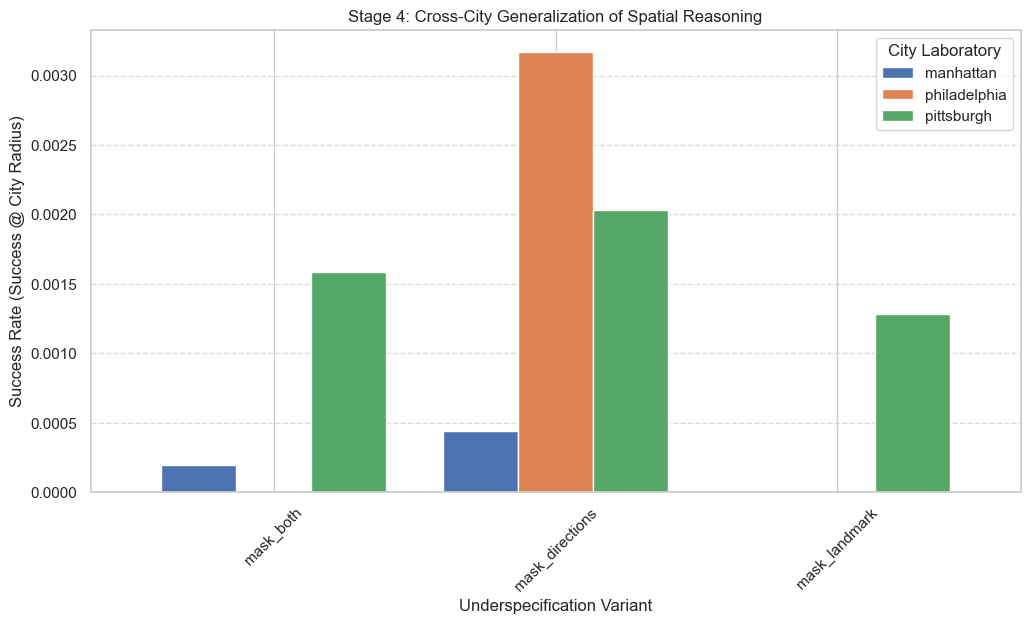

In [49]:
# The "Cross-City Generalization" Radar

# Create a pivot table of Success Rate by City and Variant
radar_data = eval_df.groupby(['city', 'variant_type'])['is_success'].mean().unstack()

# Plotting a comparison of how 'Masking' hurts different cities
radar_data.T.plot(kind='bar', figsize=(12, 6), width=0.8)
plt.title("Stage 4: Cross-City Generalization of Spatial Reasoning")
plt.ylabel("Success Rate (Success @ City Radius)")
plt.xlabel("Underspecification Variant")
plt.xticks(rotation=45)
plt.legend(title="City Laboratory")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Diagnose why orange is missing from mask_both and mask_landmark

In [51]:
# Check the raw percentages for Philly
philly_stats = eval_df[eval_df['city'] == 'philadelphia'].groupby('variant_type')['is_success'].mean() * 100
print("--- Philadelphia Success Rates (%) ---")
print(philly_stats)

--- Philadelphia Success Rates (%) ---
variant_type
mask_directions    0.316957
Name: is_success, dtype: float64


In [52]:
print("Value counts for all variants in the whole dataset:")
print(eval_df['variant_type'].value_counts())

print("\nValue counts for Philadelphia specifically:")
print(eval_df[eval_df['city'] == 'philadelphia']['variant_type'].value_counts())

Value counts for all variants in the whole dataset:
variant_type
mask_directions    9069
mask_landmark      7265
mask_both          5839
Name: count, dtype: int64

Value counts for Philadelphia specifically:
variant_type
mask_directions    1262
Name: count, dtype: int64


In [53]:
print("--- Raw Results Check (Before Merge) ---")
print(results[results['city'] == 'philadelphia']['variant_type'].value_counts())

--- Raw Results Check (Before Merge) ---
variant_type
mask_directions    1262
Name: count, dtype: int64


In [50]:
# The "Consistent World" Check (Projection Validity)

# Create a pool of all valid coordinates in the city
all_valid_nodes = master_gold[['oracle_lat', 'oracle_lon']].dropna().values

def check_world_consistency(pred_lat, pred_lon, valid_pool, threshold=100):
    # Quick distance check to the nearest valid world-node
    # This is a proxy for "Did the LLM guess a real street?"
    distances = haversine_vectorized(pred_lat, pred_lon, valid_pool[:,0], valid_pool[:,1])
    return np.min(distances) <= threshold

# Apply to a sample (it's computationally heavy for 22k rows)
sample_eval = eval_df.dropna(subset=['pred_lat']).sample(min(500, len(eval_df)))
sample_eval['on_map'] = sample_eval.apply(lambda r: check_world_consistency(r.pred_lat, r.pred_lon, all_valid_nodes), axis=1)

on_map_pct = sample_eval['on_map'].mean() * 100
print(f"🌍 World Consistency Score: {on_map_pct:.1f}% of LLM predictions landed within 100m of a known map node.")

🌍 World Consistency Score: 92.2% of LLM predictions landed within 100m of a known map node.


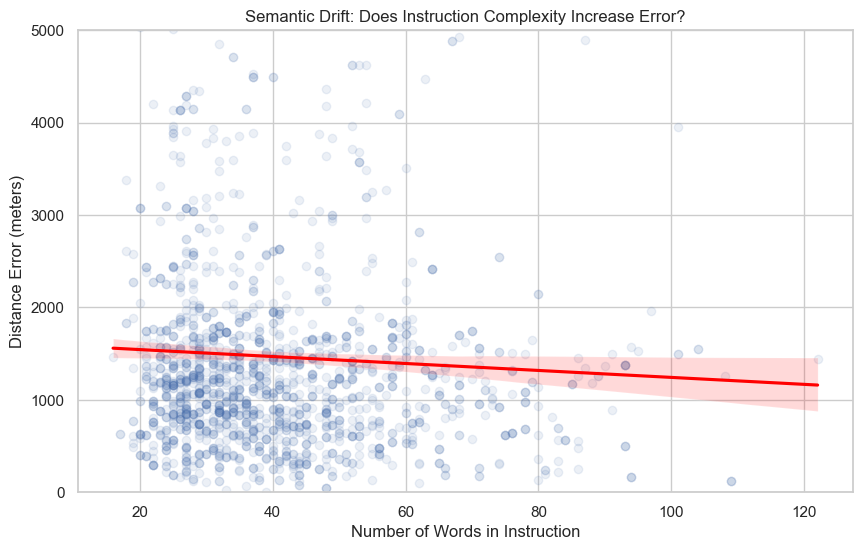

In [69]:
# The "Semantic Drift" Plot

# Create a plot to see if 'more info' makes the LLM 'more wrong'
eval_df['instruction_length'] = eval_df['instruction'].str.split().str.len()

plt.figure(figsize=(10, 6))
sns.regplot(data=eval_df[eval_df['llm_behavior'] == 'LLM: Decisive'], 
            x='instruction_length', y='dist_error', 
            scatter_kws={'alpha':0.1}, line_kws={'color':'red'})

plt.title("Semantic Drift: Does Instruction Complexity Increase Error?")
plt.xlabel("Number of Words in Instruction")
plt.ylabel("Distance Error (meters)")
plt.ylim(0, 5000) # Focus on the local neighborhood
plt.show()

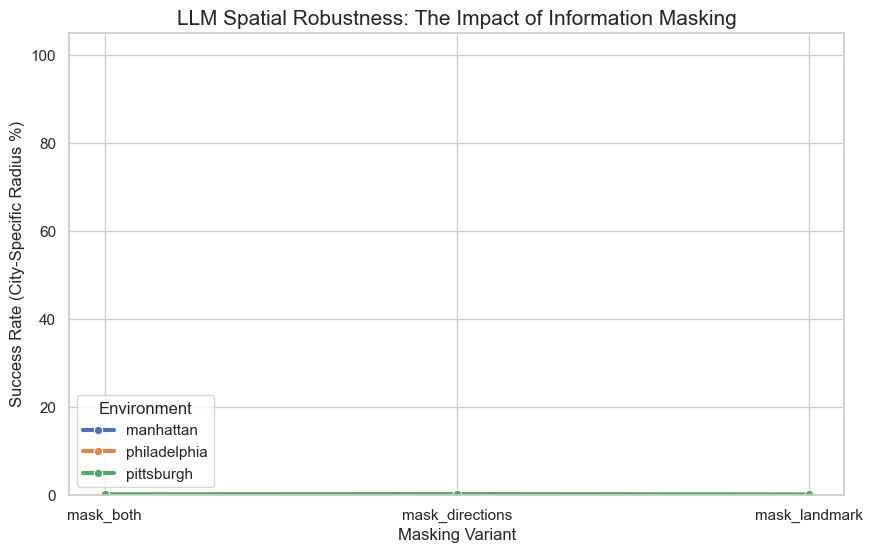

In [ ]:
# The "Robustness Decay" Plot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Aggregate success by city and mask type
plot_data = eval_df.groupby(['city', 'variant_type'])['is_success'].mean().reset_index()
plot_data['is_success'] *= 100

sns.lineplot(data=plot_data, x='variant_type', y='is_success', hue='city', marker='o', linewidth=3)

plt.title("LLM Spatial Robustness: The Impact of Information Masking", fontsize=15)
plt.ylabel("Success Rate (City-Specific Radius %)", fontsize=12)
plt.xlabel("Masking Variant", fontsize=12)
plt.ylim(0, 105)
plt.legend(title="Environment", loc='lower left')
plt.savefig('../reports/plots/robustness_decay_final.png', dpi=300)
plt.show()

BBBBBBBBBBBBBBBBBBB-END

In [1]:
# --- GLOBAL AUDITOR: INSPECT ANY ROW ---
# We can change the index to inspect different failures
inspect_index = 0 

# Filtering for Decisive Failures to see why the LLM was overconfident
decisive_failures = eval_df[(eval_df['llm_behavior'] == 'LLM: Decisive') & (eval_df['is_success'] == False)]

if not decisive_failures.empty:
    target = decisive_failures.iloc[inspect_index]
    print(f"📍 INSPECTING FAILURE AT INDEX: {inspect_index}")
    print("-" * 50)
    print(f"📖 Instruction: {target['instruction']}")
    print(f"🏙️ City: {target['city']}")
    print(f"🤖 LLM Output: {target['llm_output_raw']}")
    print(f"🎯 Oracle: ({target['oracle_lat']:.5f}, {target['oracle_lon']:.5f})")
    print(f"📍 Predicted: ({target['pred_lat']:.5f}, {target['pred_lon']:.5f})")
    print(f"📏 Error: {target['dist_error']:.2f} meters")
    print("-" * 50)
else:
    print("No decisive failures found in current slice.")

NameError: name 'eval_df' is not defined